# EDA — Smart eCommerce Intelligence Pipeline

Load `data/processed/cleaned_products.parquet` or `features.parquet` and explore distributions, KPIs, and first charts for the report.

In [3]:
import pandas as pd
from pathlib import Path

DATA = Path("../data")
processed = DATA / "processed"
df = pd.read_parquet(processed / "cleaned_products.parquet") if (processed / "cleaned_products.parquet").exists() else pd.DataFrame()
df.shape

(565, 15)

Cleaned products: (565, 15)
Features table:   (565, 25)

Columns: ['source_platform', 'shop_name', 'product_id', 'product_url', 'title', 'description', 'category', 'brand', 'price', 'old_price', 'availability', 'rating', 'review_count', 'geography', 'scraped_at']

=== DATASET OVERVIEW ===
Total products: 565
Shops: 8
Platforms: {'woocommerce': 404, 'shopify': 161}

Products per shop:


shop_name
NutriBullet          184
Dan-O's Seasoning    128
Nalgene               92
Fashion Nova          61
Ruggable              47
Death Wish Coffee     29
Turtle Beach          22
Hiut Denim             2
Name: count, dtype: int64


Sample products:


,title,shop_name,category,price,rating,geography
0,London Stripe Polo Fold Over Waistband Short S...,Fashion Nova,uncategorized,NaN,NaN,US
1,Bianca Seamless Scoop Neck Tank Top Fncolornam...,Fashion Nova,uncategorized,NaN,5.000000,US
2,Josie Fringe Washed Mid Rise Flare Pant 33 Bla...,Fashion Nova,uncategorized,NaN,5.000000,US
3,Fck What They Think Graphic Tee Black,Fashion Nova,uncategorized,NaN,4.583893,US
4,Attitude Runs Deep Oversized Tee Black,Fashion Nova,uncategorized,NaN,4.386363,US
5,No Off Days Hardware Scarf Denim Halter Top Da...,Fashion Nova,uncategorized,NaN,NaN,US
6,Ava Button Up Short Set Chocolate,Fashion Nova,uncategorized,NaN,NaN,US
7,Raina Smocked Linen Maxi Dress Black,Fashion Nova,uncategorized,NaN,NaN,US
8,Bianca Seamless Padded Scoop Neck Tank Top Black,Fashion Nova,uncategorized,NaN,5.000000,US
9,Pretty Player Bodysuit Legging Set Charcoal,Fashion Nova,uncategorized,NaN,NaN,US



=== FIELD COVERAGE ===
  price: 433/565 (77%)
  old_price: 88/565 (16%)
  rating: 96/565 (17%)
  review_count: 96/565 (17%)
  category: 419/565 (74%)
  description: 555/565 (98%)
  availability: 29/565 (5%)
  geography: 565/565 (100%)

=== NUMERIC DESCRIPTION (features) ===


...

category
uncategorized    146
accessories      123
warranty          52
runner rugs       46
combos            31
by shape          28
blenders          22
supplements       15
containers        14
cheesonings       12
customizer         9
coffee             8
everyday           7
hats               7
outlaws            6
Name: count, dtype: int64


=== TOP CATEGORIES BY POPULARITY PROXY ===


category
kids water bottles    0.403043
water bottles         0.341517
everyday              0.260143
containers            0.218826
outdoors              0.205638
by shape              0.138619
uncategorized         0.121096
storage & brewing     0.069375
merchandise           0.037515
accessories           0.028383
cheesonings           0.017993
bundle                0.016024
Name: popularity_proxy, dtype: float64


=== GEOGRAPHY ===


geography
US    563
UK      2
Name: count, dtype: int64

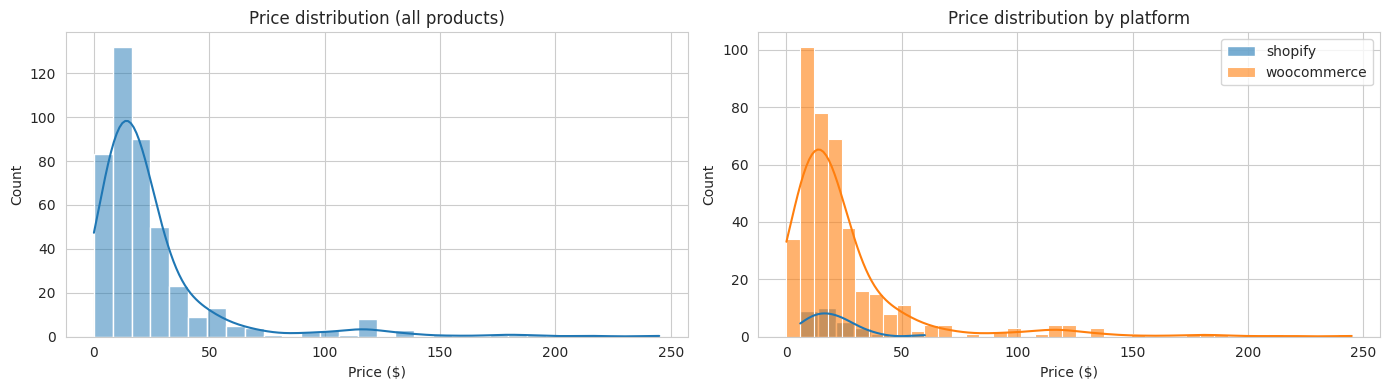

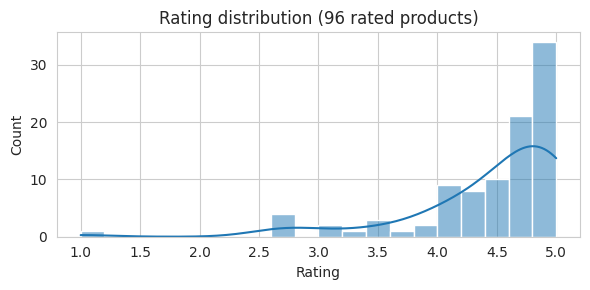

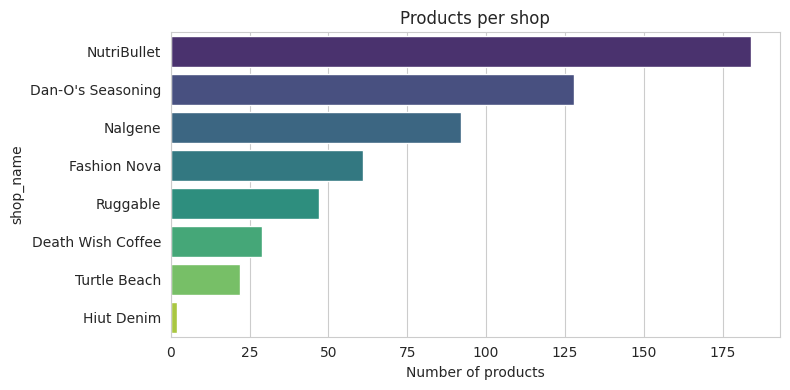

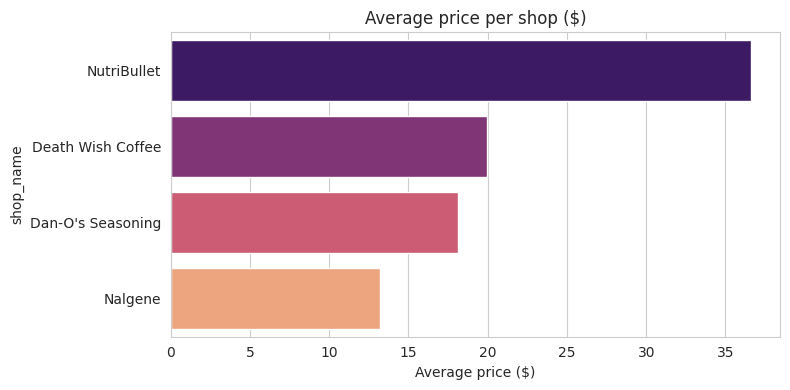

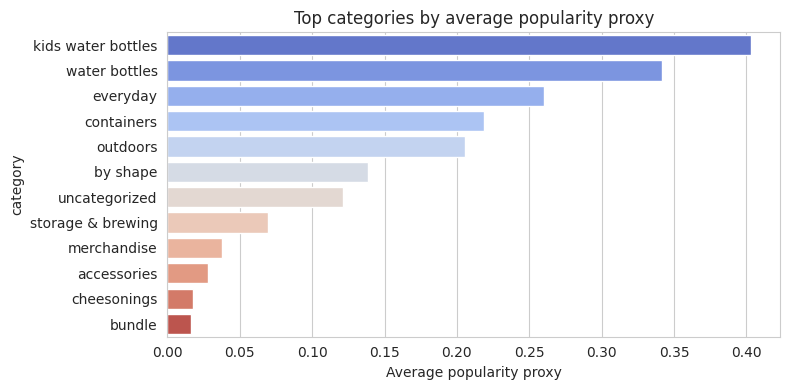

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_style("whitegrid")

# Load features table
features_path = processed / "features.parquet"
df_feat = pd.read_parquet(features_path) if features_path.exists() else pd.DataFrame()

print(f"Cleaned products: {df.shape}")
print(f"Features table:   {df_feat.shape}")
print(f"\nColumns: {list(df.columns)}")

# ──────────────────────────────────────
# 1. Dataset overview
# ──────────────────────────────────────
print("\n=== DATASET OVERVIEW ===")
print(f"Total products: {len(df)}")
print(f"Shops: {df['shop_name'].nunique()}")
print(f"Platforms: {df['source_platform'].value_counts().to_dict()}")

print("\nProducts per shop:")
display(df["shop_name"].value_counts())

print("\nSample products:")
display(df[["title", "shop_name", "category", "price", "rating", "geography"]].head(10))

# ──────────────────────────────────────
# 2. Field coverage
# ──────────────────────────────────────
print("\n=== FIELD COVERAGE ===")
total = len(df)
for col in ["price", "old_price", "rating", "review_count", "category", "description", "availability", "geography"]:
    if col in df.columns:
        if df[col].dtype == object:
            non_null = (df[col].notna() & ~df[col].isin(["", "unknown", "uncategorized"])).sum()
        else:
            non_null = df[col].notna().sum()
            if col in ("rating", "review_count"):
                non_null = (df[col].fillna(0) > 0).sum()
        print(f"  {col}: {non_null}/{total} ({100*non_null/total:.0f}%)")

# ──────────────────────────────────────
# 3. Numeric description
# ──────────────────────────────────────
if not df_feat.empty:
    print("\n=== NUMERIC DESCRIPTION (features) ===")
    display(df_feat[["price", "old_price", "rating", "review_count",
                      "discount_pct", "popularity_proxy", "description_length"]].describe())

# ──────────────────────────────────────
# 4. Category distribution
# ──────────────────────────────────────
if "category" in df.columns:
    print("\n=== TOP 15 CATEGORIES ===")
    display(df["category"].value_counts().head(15))

# ──────────────────────────────────────
# 5. Price distribution (by platform)
# ──────────────────────────────────────
if not df_feat.empty and "price" in df_feat.columns:
    prices = df_feat["price"].dropna()
    if not prices.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.histplot(prices, kde=True, ax=axes[0], bins=30)
        axes[0].set_title("Price distribution (all products)")
        axes[0].set_xlabel("Price ($)")

        if "source_platform" in df_feat.columns:
            for platform in df_feat["source_platform"].unique():
                subset = df_feat[df_feat["source_platform"] == platform]["price"].dropna()
                if not subset.empty:
                    sns.histplot(subset, kde=True, ax=axes[1], label=platform, alpha=0.6)
            axes[1].set_title("Price distribution by platform")
            axes[1].set_xlabel("Price ($)")
            axes[1].legend()
        plt.tight_layout()

# ──────────────────────────────────────
# 6. Rating distribution (where available)
# ──────────────────────────────────────
if not df_feat.empty and "rating" in df_feat.columns:
    rated = df_feat[df_feat["rating"].fillna(0) > 0]
    if not rated.empty:
        fig, ax = plt.subplots(figsize=(6, 3))
        sns.histplot(rated["rating"], kde=True, ax=ax, bins=20)
        ax.set_title(f"Rating distribution ({len(rated)} rated products)")
        ax.set_xlabel("Rating")
        plt.tight_layout()
    else:
        print("\nNo products with rating > 0.")

# ──────────────────────────────────────
# 7. Products per shop (bar chart)
# ──────────────────────────────────────
if "shop_name" in df.columns:
    shop_counts = df["shop_name"].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=shop_counts.values, y=shop_counts.index, ax=ax, hue=shop_counts.index, legend=False, palette="viridis")
    ax.set_title("Products per shop")
    ax.set_xlabel("Number of products")
    plt.tight_layout()

# ──────────────────────────────────────
# 8. Average price per shop
# ──────────────────────────────────────
if not df_feat.empty and {"shop_name", "price"}.issubset(df_feat.columns):
    avg_price = df_feat.groupby("shop_name")["price"].mean().dropna().sort_values(ascending=False)
    if not avg_price.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.barplot(x=avg_price.values, y=avg_price.index, ax=ax, hue=avg_price.index, legend=False, palette="magma")
        ax.set_title("Average price per shop ($)")
        ax.set_xlabel("Average price ($)")
        plt.tight_layout()

# ──────────────────────────────────────
# 9. Popularity proxy by category
# ──────────────────────────────────────
if not df_feat.empty and {"category", "popularity_proxy"}.issubset(df_feat.columns):
    pop_by_cat = (
        df_feat.groupby("category")["popularity_proxy"]
        .mean()
        .sort_values(ascending=False)
        .head(12)
    )
    print("\n=== TOP CATEGORIES BY POPULARITY PROXY ===")
    display(pop_by_cat)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=pop_by_cat.values, y=pop_by_cat.index, ax=ax, hue=pop_by_cat.index, legend=False, palette="coolwarm")
    ax.set_title("Top categories by average popularity proxy")
    ax.set_xlabel("Average popularity proxy")
    plt.tight_layout()

# ──────────────────────────────────────
# 10. Geography breakdown
# ──────────────────────────────────────
if "geography" in df.columns:
    print("\n=== GEOGRAPHY ===")
    display(df["geography"].value_counts())

## Notes for report (Phase 3.3)

- **Data volume:** 220 products in total, coming from **2 shops** (`Ruggable` with 92 products and `Dan-O's Seasoning` with 128 products). The cleaned table has 15 base columns that match the `ProductRecord` schema.

- **Price distribution:** Prices (available for the WooCommerce products) are **highly skewed**. The median price is around **1 149** while a few bundles go up to about **15 500**, which creates a long right tail. Most products are in the low to mid price range.

- **Ratings / reviews:** In this first iteration, **ratings and review counts are effectively zero or missing for all products**, so user engagement cannot be modeled directly. This motivates the use of engineered proxy features (discount, stock, category competitiveness) instead of raw ratings.

- **Category profile:** We observe **7 main categories**: `combos`, `cheesonings`, `accessories`, `hats`, `outlaws`, `dip mixes`, and `merchandise`. `combos` and `cheesonings` are the largest groups, while categories like `dip mixes` and `merchandise` have fewer products but still contribute to the catalog.

- **Popularity proxy:** Using the engineered `popularity_proxy` (combining rating, review count, stock status, and discount), the top categories by average score are **`merchandise`**, followed by **`cheesonings`** and **`combos`**. In this dataset the proxy is mainly driven by discounts and stock, since ratings are not informative yet.

- **Data quality points:**
  - Duplicates are removed using (`source_platform`, `shop_name`, `product_id`) so each product appears once.
  - v1 Shopify products lacked numeric fields; v2 enriches via `/products/<slug>.json` (price, description, category, brand).
  - WooCommerce prices were in cents in v1; v2 divides by `currency_minor_unit`.
  - HTML stripped from descriptions via BeautifulSoup.

### v2 dataset (565 products, 8 shops, 6 niches)
- **Price:** median ~$17, mean ~$25, max ~$245 (in real dollars now).
- **Ratings:** 96 products (17%) have ratings > 0 (mainly Turtle Beach via JSON-LD).
- **Categories:** 15+ distinct, 74% coverage (up from 32%).
- **Geography:** 100% (563 US, 2 UK).
- **ML:** RF CV F1=0.996, KMeans silhouette=0.261 (more diverse data), 874 association rules, 56 DBSCAN outliers.
- **Remaining gaps:** 23% still lack prices (some Shopify stores block `.json`), 146 "uncategorized", ratings sparse.